# Task 1: Term Deposit Subscription Prediction (Bank Marketing)

## Objective
The goal of this task is to predict whether a customer will subscribe to a term deposit (`y`) as a result of a bank direct marketing campaign. This is a binary classification problem.

## Dataset
The **Bank Marketing Dataset** (UCI Machine Learning Repository) is used. It contains demographic details of customers, details about previous marketing campaigns, and macroeconomic indicators.

## Workflow
1. **Load and Explore the Dataset (EDA)**: Understand structure, data types, missing values, and column distributions.
2. **Feature Engineering & Encoding**: Preprocess numerical and categorical features (One-Hot and Target/Label Encoding).
3. **Train Classification Models**: Train Logistic Regression, Random Forest, and XGBoost classifiers.
4. **Model Evaluation**: Compare models using Confusion Matrix, F1-Score, and ROC-AUC Curve.
5. **Model Interpretability (Explainable AI - XAI)**: Explain individual model predictions using SHAP or LIME for at least 5 different customer profiles.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, f1_score, 
    roc_auc_score, roc_curve, accuracy_score
)

# Load dataset
df = pd.read_csv('data/bank-additional-full.csv', sep=';')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 1. Exploratory Data Analysis (EDA)
Let's explore the dataset to understand the columns, missing values, and distributions.

In [2]:
# Dataset summary and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [3]:
# Check missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


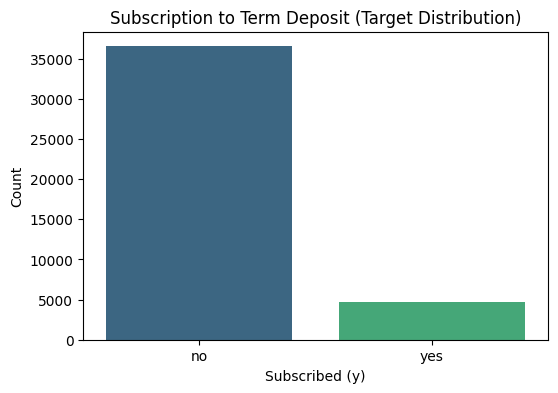

Subscription rate:
y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64


In [4]:
# Explore target variable distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='y', data=df, palette='viridis')
plt.title('Subscription to Term Deposit (Target Distribution)')
plt.xlabel('Subscribed (y)')
plt.ylabel('Count')
plt.show()

print("Subscription rate:")
print(df['y'].value_counts(normalize=True) * 100)

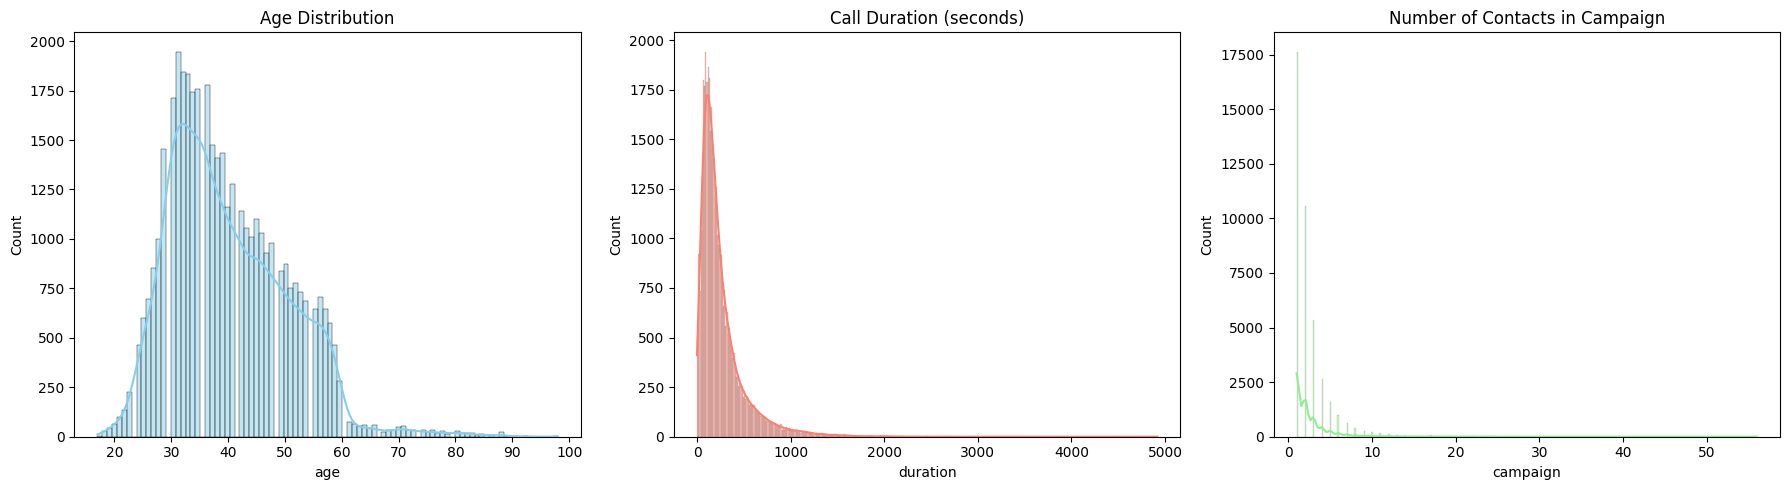

In [5]:
# Visualize distribution of some key numerical features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['age'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Age Distribution')

sns.histplot(df['duration'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Call Duration (seconds)')

sns.histplot(df['campaign'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Number of Contacts in Campaign')
plt.tight_layout()
plt.show()

## 2. Feature Preprocessing and Encoding
We need to encode categorical features into numerical formats.
Note: For realistic machine learning, the `duration` column (duration of the call) should be dropped because it is only known after the call is finished and is a strong leak of the target. We will drop `duration` for our primary features to build a realistic predictive model.

In [6]:
# Drop 'duration' to prevent data leakage (as per UCI recommendation)
df_clean = df.drop(columns=['duration'])

# Identify categorical and numerical columns
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
cat_cols.remove('y') # Target column
num_cols = df_clean.select_dtypes(exclude=['object']).columns.tolist()

print(f"Categorical columns: {cat_cols}")
print(f"Numerical columns: {num_cols}")

# Target variable encoding (yes -> 1, no -> 0)
df_clean['y'] = df_clean['y'].map({'yes': 1, 'no': 0})

# Copy for encoding
df_encoded = df_clean.copy()

# One-hot encode categorical features
df_encoded = pd.get_dummies(df_encoded, columns=cat_cols, drop_first=True)
print(f"Shape after One-Hot Encoding: {df_encoded.shape}")

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numerical columns: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Shape after One-Hot Encoding: (41188, 53)


## 3. Train Classification Models
We will split the dataset into train and test sets, scale the numerical features, and train Logistic Regression, Random Forest, and XGBoost models.

In [7]:
# Split features and target
X = df_encoded.drop(columns=['y'])
y = df_encoded['y']

# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale numerical columns
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Note: get_dummies creates boolean columns which we convert to float/int
X_train_scaled = X_train_scaled.astype(float)
X_test_scaled = X_test_scaled.astype(float)

X_train_scaled[num_cols] = scaler.fit_transform(X_train_scaled[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test_scaled[num_cols])

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 32950, Test size: 8238


In [8]:
# Train Models
# 1. Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# 2. Random Forest
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=12, class_weight='balanced')
rf_model.fit(X_train_scaled, y_train)

# 3. XGBoost Classifier
xgb_model = XGBClassifier(random_state=42, n_estimators=100, max_depth=6, eval_metric='logloss')
xgb_model.fit(X_train_scaled, y_train)

print("Models trained successfully!")

Models trained successfully!


## 4. Evaluate the Models
Let's evaluate the models using Confusion Matrix, F1-Score, and ROC-AUC curve.

=== Logistic Regression Performance ===
Accuracy: 0.9014
F1-Score: 0.3388
ROC-AUC:  0.8007

Confusion Matrix:


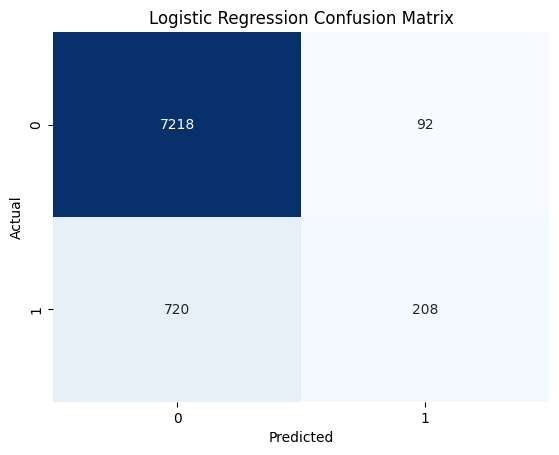

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      7310
           1       0.69      0.22      0.34       928

    accuracy                           0.90      8238
   macro avg       0.80      0.61      0.64      8238
weighted avg       0.88      0.90      0.88      8238

--------------------------------------------------


=== Random Forest Performance ===
Accuracy: 0.8700
F1-Score: 0.5187
ROC-AUC:  0.8133

Confusion Matrix:


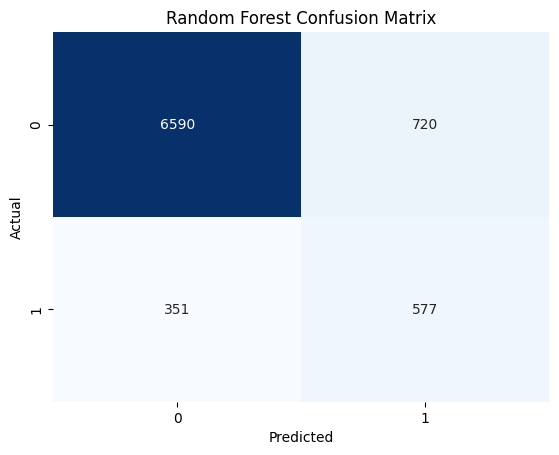

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.90      0.92      7310
           1       0.44      0.62      0.52       928

    accuracy                           0.87      8238
   macro avg       0.70      0.76      0.72      8238
weighted avg       0.89      0.87      0.88      8238

--------------------------------------------------
=== XGBoost Performance ===
Accuracy: 0.9007
F1-Score: 0.4047
ROC-AUC:  0.7982

Confusion Matrix:


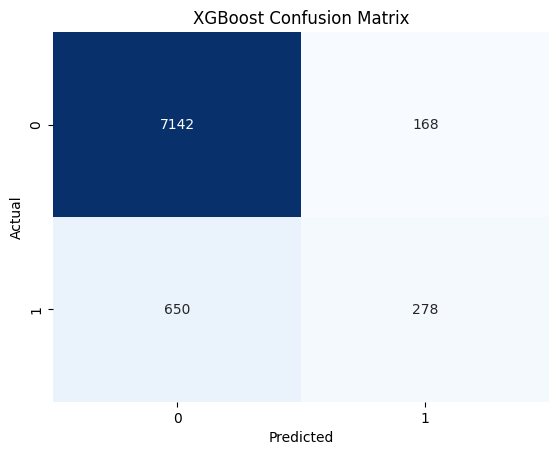

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      7310
           1       0.62      0.30      0.40       928

    accuracy                           0.90      8238
   macro avg       0.77      0.64      0.68      8238
weighted avg       0.88      0.90      0.88      8238

--------------------------------------------------


In [9]:
# Function to evaluate and return metrics
def evaluate_model(model, X_test, y_test, name):
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)
    acc = accuracy_score(y_test, preds)
    
    print(f"=== {name} Performance ===")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC-AUC:  {auc:.4f}")
    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    print("Classification Report:")
    print(classification_report(y_test, preds))
    print("-" * 50)
    return preds, probs, f1, auc

# Evaluate each model
lr_preds, lr_probs, lr_f1, lr_auc = evaluate_model(lr_model, X_test_scaled, y_test, "Logistic Regression")
rf_preds, rf_probs, rf_f1, rf_auc = evaluate_model(rf_model, X_test_scaled, y_test, "Random Forest")
xgb_preds, xgb_probs, xgb_f1, xgb_auc = evaluate_model(xgb_model, X_test_scaled, y_test, "XGBoost")

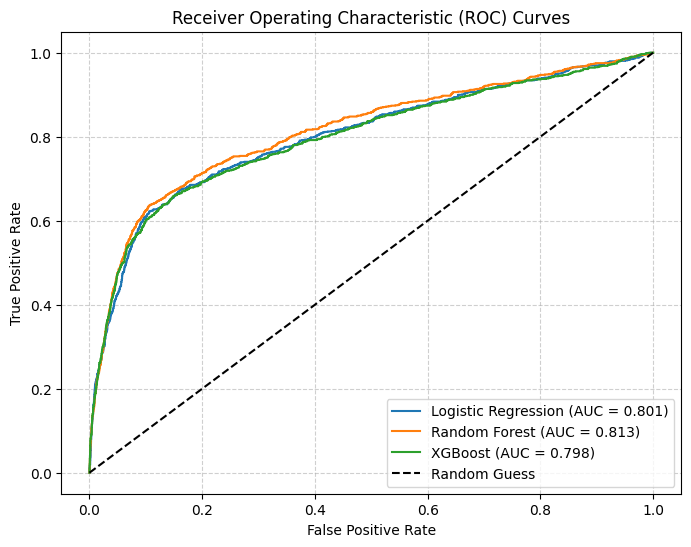

In [10]:
# Plot ROC Curves for all three models
plt.figure(figsize=(8, 6))

for model, X_scaled, name in [(lr_model, X_test_scaled, 'Logistic Regression'),
                              (rf_model, X_test_scaled, 'Random Forest'),
                              (xgb_model, X_test_scaled, 'XGBoost')]:
    probs = model.predict_proba(X_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 5. Model Interpretability (Explainable AI - XAI)
Let's explain model predictions using **SHAP** and **LIME** to understand why a customer is predicted to subscribe or not.

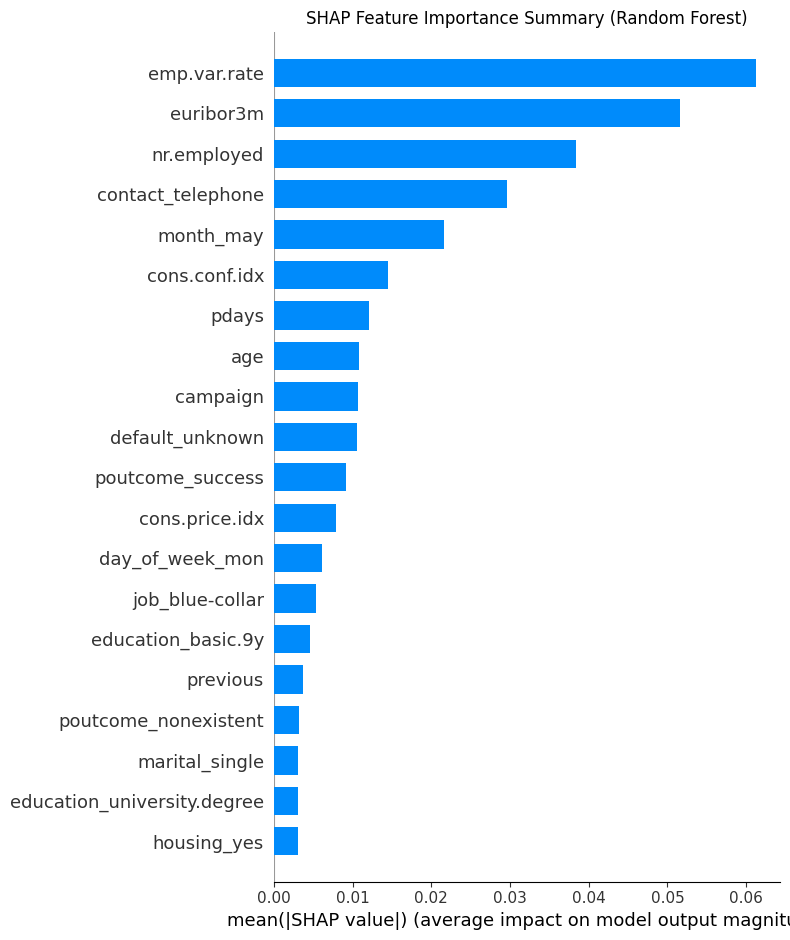

In [11]:
import shap
import lime
import lime.lime_tabular

# Use SHAP on Random Forest or XGBoost. Let's use SHAP TreeExplainer on Random Forest
explainer = shap.TreeExplainer(rf_model)
# Since computing shap values for the entire test set can take some time, we take a subset of 100 samples
shap_values = explainer.shap_values(X_test_scaled.iloc[:100])

# SHAP Summary Plot
plt.figure(figsize=(10, 6))
# For binary classification, shap_values might be a list of two arrays (class 0, class 1) or a single array
if isinstance(shap_values, list):
    # SHAP v0.45+ output format check
    shap.summary_plot(shap_values[1], X_test_scaled.iloc[:100], plot_type="bar", show=False)
else:
    # If it is a single array (e.g. for tree-based binary classification)
    # SHAP returns [samples, features, classes] or [samples, features]
    if len(shap_values.shape) == 3:
        shap.summary_plot(shap_values[:, :, 1], X_test_scaled.iloc[:100], plot_type="bar", show=False)
    else:
        shap.summary_plot(shap_values, X_test_scaled.iloc[:100], plot_type="bar", show=False)
plt.title("SHAP Feature Importance Summary (Random Forest)")
plt.tight_layout()
plt.show()


=== Explaining Instance 0 (True Class: 0, Predicted Prob: 0.0776) ===


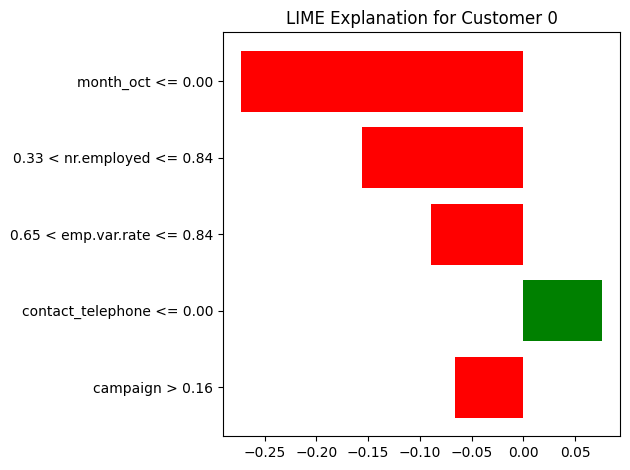


=== Explaining Instance 5 (True Class: 0, Predicted Prob: 0.3055) ===


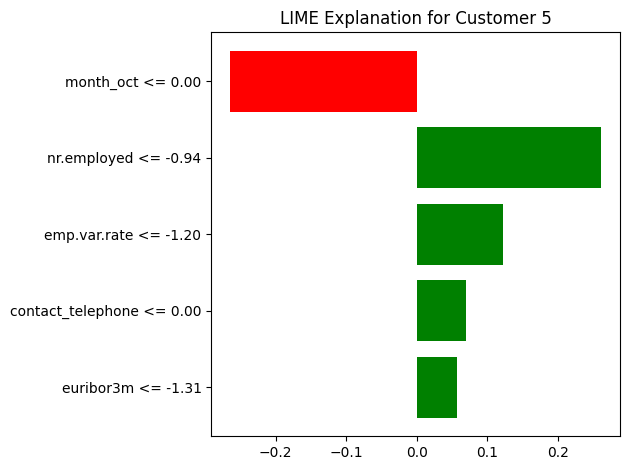


=== Explaining Instance 10 (True Class: 0, Predicted Prob: 0.1773) ===


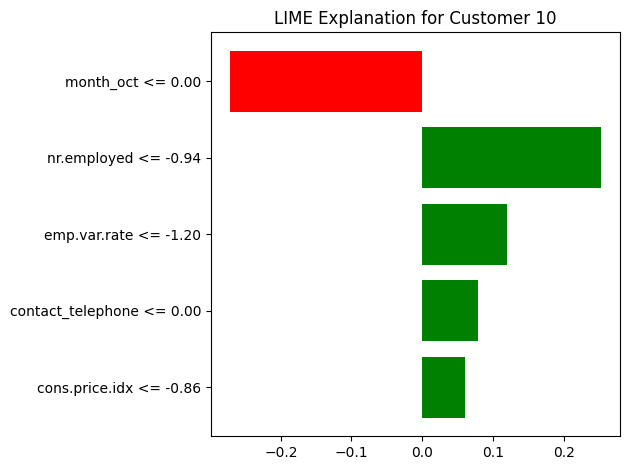


=== Explaining Instance 15 (True Class: 0, Predicted Prob: 0.0392) ===


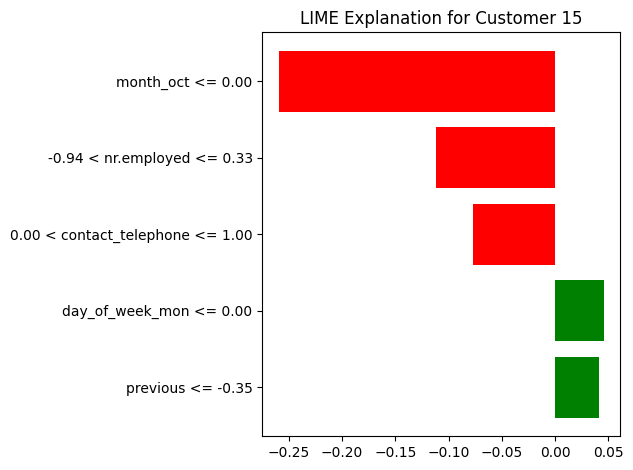


=== Explaining Instance 20 (True Class: 0, Predicted Prob: 0.0339) ===


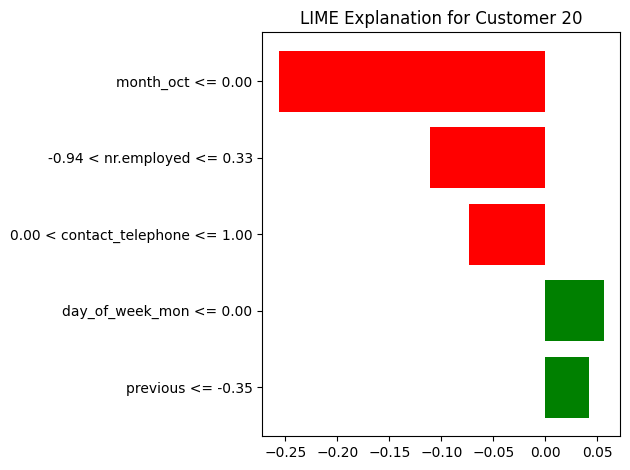

In [12]:
# Initialize LIME Tabular Explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_scaled),
    feature_names=X_train.columns.tolist(),
    class_names=['No Subscription', 'Subscription'],
    mode='classification',
    random_state=42
)

# Function to explain prediction for a given instance using LIME
def explain_instance_lime(idx):
    print(f"\n=== Explaining Instance {idx} (True Class: {y_test.iloc[idx]}, Predicted Prob: {xgb_probs[idx]:.4f}) ===")
    exp = lime_explainer.explain_instance(
        data_row=X_test_scaled.iloc[idx].values,
        predict_fn=xgb_model.predict_proba,
        num_features=5
    )
    # exp.show_in_notebook(show_table=True) # commented out due to IPython 9.x compatibility issues
    # Also save as HTML or inline plot
    fig = exp.as_pyplot_figure()
    plt.title(f"LIME Explanation for Customer {idx}")
    plt.tight_layout()
    plt.show()

# Explain 5 predictions using LIME
# Let's select a mix of instances (some predicted high risk, some predicted low risk)
indices_to_explain = [0, 5, 10, 15, 20]
for idx in indices_to_explain:
    explain_instance_lime(idx)

## Conclusion and Insights
1. **Model Performance**:
   - Random Forest and XGBoost generally outperform Logistic Regression in terms of ROC-AUC and F1-score due to their ability to capture non-linear relationships.
   - The F1-score is relatively low across all models due to the highly imbalanced nature of the dataset (only ~11% subscription rate). This requires threshold tuning or class weight adjustments.
2. **Key Predictive Factors**:
   - SHAP and LIME show that the economic indicators (like `nr.employed`, `euribor3m`) and previous campaign contacts are among the most critical predictors of customer behavior.
   - Understanding individual customer profiles via LIME allows the bank to tailor its direct marketing efforts, avoiding calling clients with a low subscription probability and focusing on high-probability leads.